In [1]:
import numpy as np
from Solver.AdvReactUni import AdvReactUni1DSolver, AdvReactUni1DEval
from Solver.FVUni2nd import FVUni2nd1D
from Solver.ODE import ESDIRK, DITRExp

Nx = 128

fv = FVUni2nd1D(nx=Nx)
ev = AdvReactUni1DEval(
    fv=fv,
    # model="bistable",
    # params={"a": 0.5, "k": 100},
)
# solver = AdvReactUni1DSolver(eval=ev, ode=ESDIRK("BackwardEuler"))
solver = AdvReactUni1DSolver(eval=ev, ode=DITRExp())

dt = 1 / Nx * 0.5 * 1
tEnd = 1

u = np.array([np.sin(fv.xcs * np.pi * 2)]) * 1 + 0

# u1 = solver.stepInterval(dt, u, 0.0, tEnd)

solverDITR = AdvReactUni1DSolver(eval=ev, ode=DITRExp())

u1Ditr = solverDITR.stepInterval(
    dt,
    u,
    0.0,
    tEnd,
    solve_opts={
        "rel_tol": 1e-4,
        "CFL": 10,
    },
    use_exp=True,
)

iter [[0.5, 1],6], resN [3.4512e-03 / 4.5092e+01]
Step [1], t = [3.9062e-03] uNorm [8.00033519388599]
iter [[0.5, 1],6], resN [3.4887e-03 / 4.5093e+01]
Step [2], t = [7.8125e-03] uNorm [8.00067039789658]
iter [[0.5, 1],6], resN [3.4495e-03 / 4.5095e+01]
Step [3], t = [1.1719e-02] uNorm [8.001005639466268]
iter [[0.5, 1],6], resN [3.5270e-03 / 4.5097e+01]
Step [4], t = [1.5625e-02] uNorm [8.001340802031278]
iter [[0.5, 1],6], resN [3.4494e-03 / 4.5099e+01]
Step [5], t = [1.9531e-02] uNorm [8.001676054099201]
iter [[0.5, 1],6], resN [3.4935e-03 / 4.5101e+01]
Step [6], t = [2.3438e-02] uNorm [8.002011234005094]
iter [[0.5, 1],6], resN [3.4475e-03 / 4.5103e+01]
Step [7], t = [2.7344e-02] uNorm [8.002346494841218]
iter [[0.5, 1],6], resN [3.4718e-03 / 4.5105e+01]
Step [8], t = [3.1250e-02] uNorm [8.002681700546516]
iter [[0.5, 1],6], resN [3.5799e-03 / 4.5107e+01]
Step [9], t = [3.5156e-02] uNorm [8.003016959590992]
iter [[0.5, 1],6], resN [3.4560e-03 / 4.5109e+01]
Step [10], t = [3.9062e-0

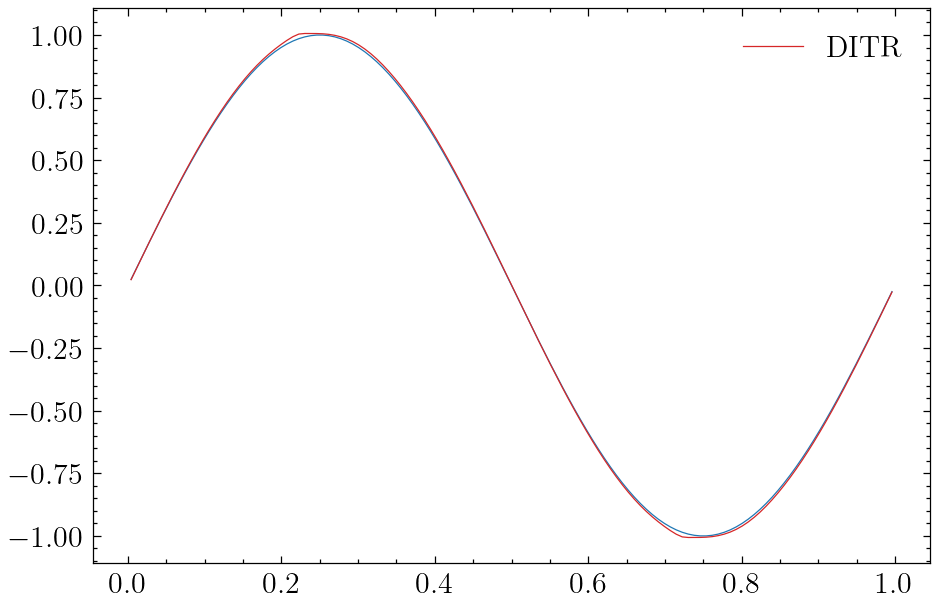

In [2]:
import matplotlib.pyplot as plt
import PlotEnv

plotEnv = PlotEnv.PlotEnv(dpi=180, markEvery=0)

fig = plotEnv.figure(101, figsize=(6, 4))
plotEnv.plot(fv.xcs, u[0], plotIndex=0)
plotEnv.plot(fv.xcs, u1Ditr[0], plotIndex=3, label="DITR")
plt.legend()
plt.show()